## Module 6: Shortest Paths

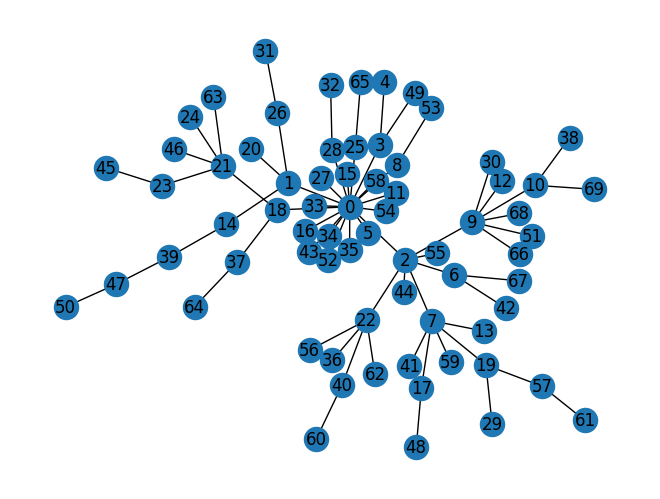

In [30]:
from graph_algorithms_the_fun_way import graph as gr
from graph_algorithms_the_fun_way import search as src
from graph_algorithms_the_fun_way import shortest_path as sp
import networkx as nx
import numpy as np


numnodes = 70

G = nx.barabasi_albert_graph(numnodes, 1, seed=42)
pos = nx.kamada_kawai_layout(G)
nx.draw(G, with_labels=True, pos=pos)


In [31]:
# Convert to GATFW graph
edgelist = list(nx.edges(G))  
print(edgelist[:10])  # Print the first 10 edges to verify

# Convert nx graph to GATFW graph
g = gr.Graph(numnodes)  # Create a new graph 
for (u, v) in edgelist:
    g.insert_edge(u, v, 1.0)  # Assuming a weight of 1.0 for each edge

for i in (g.make_edge_list()):  # Print the first 10 edges to verify
    print(i.from_node, i.to_node, i.weight)

print(f"Number of edges: {len(g.make_edge_list())}")

[(0, 1), (0, 2), (0, 3), (0, 5), (0, 8), (0, 11), (0, 15), (0, 16), (0, 18), (0, 25)]
0 1 1.0
0 2 1.0
0 3 1.0
0 5 1.0
0 8 1.0
0 11 1.0
0 15 1.0
0 16 1.0
0 18 1.0
0 25 1.0
0 27 1.0
0 28 1.0
0 33 1.0
0 34 1.0
0 35 1.0
0 43 1.0
0 52 1.0
0 54 1.0
0 58 1.0
1 14 1.0
1 20 1.0
1 26 1.0
2 6 1.0
2 7 1.0
2 9 1.0
2 22 1.0
2 44 1.0
2 55 1.0
3 4 1.0
3 49 1.0
6 42 1.0
6 67 1.0
7 13 1.0
7 17 1.0
7 19 1.0
7 41 1.0
7 59 1.0
8 53 1.0
9 10 1.0
9 12 1.0
9 30 1.0
9 51 1.0
9 66 1.0
9 68 1.0
10 38 1.0
10 69 1.0
14 39 1.0
17 48 1.0
18 21 1.0
18 37 1.0
19 29 1.0
19 57 1.0
21 23 1.0
21 24 1.0
21 46 1.0
21 63 1.0
22 36 1.0
22 40 1.0
22 56 1.0
22 62 1.0
23 45 1.0
25 65 1.0
26 31 1.0
28 32 1.0
37 64 1.0
39 47 1.0
40 60 1.0
47 50 1.0
57 61 1.0
Number of edges: 69


In [32]:
bfs = src.breadth_first_search(g, 0)
print(bfs)

[-1, 0, 0, 0, 3, 0, 2, 2, 0, 2, 9, 0, 9, 7, 1, 0, 0, 7, 0, 7, 1, 18, 2, 21, 21, 0, 1, 0, 0, 19, 9, 26, 28, 0, 0, 0, 22, 18, 10, 14, 22, 7, 6, 0, 2, 23, 21, 39, 17, 3, 47, 9, 0, 8, 0, 2, 22, 19, 0, 7, 40, 57, 22, 21, 37, 25, 9, 6, 9, 10]


In [33]:
# Dijskstra's shortest path
d = sp.Dijkstras(g, 0)
print(f"ind: {[i for i in range(len(d))]}")
print(f"dij: {d}")

print(d[3])

ind: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69]
dij: [-1, 0, 0, 0, 3, 0, 2, 2, 0, 2, 9, 0, 9, 7, 1, 0, 0, 7, 0, 7, 1, 18, 2, 21, 21, 0, 1, 0, 0, 19, 9, 26, 28, 0, 0, 0, 22, 18, 10, 14, 22, 7, 6, 0, 2, 23, 21, 39, 17, 3, 47, 9, 0, 8, 0, 2, 22, 19, 0, 7, 40, 57, 22, 21, 37, 25, 9, 6, 9, 10]
0


In [34]:
# verifying shortest paths from Dijkstras list above

def Dijkstra_node_list(d, start):
    d_path = []
    d_path.append(start)

    indx = start
    while d[indx] != -1: 
        d_path.append(d[indx])
        indx = d[indx]
    return d_path


for i in range(len(d)):
    print(f"{i} to 0: {Dijkstra_node_list(d=d, start=i)}")

print(f"\nDiameter: {nx.diameter(G)}")


0 to 0: [0]
1 to 0: [1, 0]
2 to 0: [2, 0]
3 to 0: [3, 0]
4 to 0: [4, 3, 0]
5 to 0: [5, 0]
6 to 0: [6, 2, 0]
7 to 0: [7, 2, 0]
8 to 0: [8, 0]
9 to 0: [9, 2, 0]
10 to 0: [10, 9, 2, 0]
11 to 0: [11, 0]
12 to 0: [12, 9, 2, 0]
13 to 0: [13, 7, 2, 0]
14 to 0: [14, 1, 0]
15 to 0: [15, 0]
16 to 0: [16, 0]
17 to 0: [17, 7, 2, 0]
18 to 0: [18, 0]
19 to 0: [19, 7, 2, 0]
20 to 0: [20, 1, 0]
21 to 0: [21, 18, 0]
22 to 0: [22, 2, 0]
23 to 0: [23, 21, 18, 0]
24 to 0: [24, 21, 18, 0]
25 to 0: [25, 0]
26 to 0: [26, 1, 0]
27 to 0: [27, 0]
28 to 0: [28, 0]
29 to 0: [29, 19, 7, 2, 0]
30 to 0: [30, 9, 2, 0]
31 to 0: [31, 26, 1, 0]
32 to 0: [32, 28, 0]
33 to 0: [33, 0]
34 to 0: [34, 0]
35 to 0: [35, 0]
36 to 0: [36, 22, 2, 0]
37 to 0: [37, 18, 0]
38 to 0: [38, 10, 9, 2, 0]
39 to 0: [39, 14, 1, 0]
40 to 0: [40, 22, 2, 0]
41 to 0: [41, 7, 2, 0]
42 to 0: [42, 6, 2, 0]
43 to 0: [43, 0]
44 to 0: [44, 2, 0]
45 to 0: [45, 23, 21, 18, 0]
46 to 0: [46, 21, 18, 0]
47 to 0: [47, 39, 14, 1, 0]
48 to 0: [48, 17, 7, 2, 0

In [35]:
# Floyd Warshall
fw = sp.FloydWarshall(g)

# Display matrix neatly
def display_matrix(matrix: list[list]):    # 1. Find the maximum width of any number in the matrix
    max_width = 0
    for row in matrix:
        for element in row:
            if len(str(element)) > max_width:
                max_width = len(str(element))

    # 2. Print the matrix with aligned columns
    for row in matrix:
        print("[", end="")
        for i, element in enumerate(row):
            # Use an f-string with the dynamic width for right alignment (>)
            print(f"{element:>{max_width}}", end="")
            if i < len(row) - 1:
                print(", ", end="")
        print("]")

display_matrix(fw)

[-1,  0,  0,  0,  3,  0,  2,  2,  0,  2,  9,  0,  9,  7,  1,  0,  0,  7,  0,  7,  1, 18,  2, 21, 21,  0,  1,  0,  0, 19,  9, 26, 28,  0,  0,  0, 22, 18, 10, 14, 22,  7,  6,  0,  2, 23, 21, 39, 17,  3, 47,  9,  0,  8,  0,  2, 22, 19,  0,  7, 40, 57, 22, 21, 37, 25,  9,  6,  9, 10]
[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,  1, -1, -1, -1, -1, -1,  1, -1, -1, -1, -1, -1,  1, -1, -1, -1, -1, 26, -1, -1, -1, -1, -1, -1, -1, 14, -1, -1, -1, -1, -1, -1, -1, 39, -1, -1, 47, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1]
[-1, -1, -1, -1, -1, -1,  2,  2, -1,  2,  9, -1,  9,  7, -1, -1, -1,  7, -1,  7, -1, -1,  2, -1, -1, -1, -1, -1, -1, 19,  9, -1, -1, -1, -1, -1, 22, -1, 10, -1, 22,  7,  6, -1,  2, -1, -1, -1, 17, -1, -1,  9, -1, -1, -1,  2, 22, 19, -1,  7, 40, 57, 22, -1, -1, -1,  9,  6,  9, 10]
[-1, -1, -1, -1,  3, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 